In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import io


In [3]:
df = pd.read_csv(r"C:\Users\rodio\PycharmProjects\DataMining\src\Barcode ID - BOLD - db_speciesmi_0.94mo_100maxh_25order_3-1747ff1a96cd4b8a94515fe19768c04b (1).csv")
df

,Query ID,Tree,Tax Rank,Phylum,Class,Order,Family,Subfamily,Tribe,Genus,Species,Confidence,Supporting Recs
0,P1_A_10_all.fa;658;6;ambs=0;estgaps=0,Tree,SPECIES,Arthropoda,Insecta,Diptera,Chironomidae,Orthocladiinae,NaN,Eukiefferiella,Eukiefferiella claripennis,100.0,25
1,P1_C_12_all.fa;658;8;ambs=1;estgaps=1,Tree,SPECIES,Arthropoda,Insecta,Coleoptera,Dytiscidae,Laccophilinae,NaN,Laccophilus,Laccophilus hyalinus,100.0,25
2,P1_D_9_all.fa;658;25;ambs=0;estgaps=0,Tree,GENUS,Arthropoda,Insecta,Diptera,Chironomidae,Orthocladiinae,NaN,Thienemanniella,NaN,100.0,25
3,P1_G_6_all.fa;658;25;ambs=0;estgaps=0,Tree,SPECIES,Arthropoda,Insecta,Diptera,Chironomidae,Orthocladiinae,NaN,Prodiamesa,Prodiamesa olivacea,100.0,25
4,P1_H_6_all.fa;658;25;ambs=0;estgaps=0,Tree,SPECIES,Arthropoda,Insecta,Diptera,Chironomidae,Orthocladiinae,NaN,Prodiamesa,Prodiamesa olivacea,100.0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,P5_A_11_all.fa;658;11;ambs=146;estgaps=29,Tree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
285,P5_C_9_all.fa;658;19;ambs=111;estgaps=32,Tree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
286,P5_G_6_all.fa;658;7;ambs=76;estgaps=30,Tree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
287,P6_C_2_all.fa;658;6;ambs=154;estgaps=44,Tree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


Фінальні значення для графіка:
 Class
Insecta         119
Gastropoda       62
Clitellata       53
Malacostraca     13
Інші             17
Name: count, dtype: int64


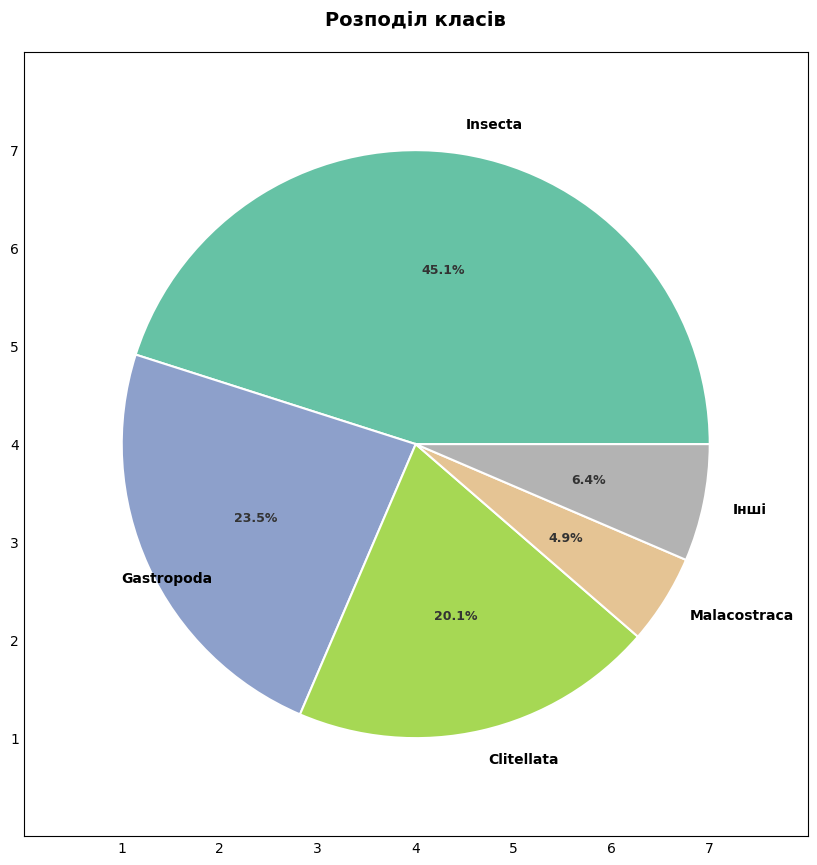

In [12]:
plt.style.use('_mpl-gallery-nogrid')

counts = df['Class'].value_counts()

mask = counts < 5
if mask.any():
    others_sum = counts[mask].sum()
    counts = counts[~mask] 
    counts['Інші'] = others_sum

print("Фінальні значення для графіка:\n", counts)

cmap = plt.get_cmap('Set2')
colors = cmap(np.linspace(0, 1, len(counts)))

fig, ax = plt.subplots(figsize=(8, 8)) 

wedges, texts, autotexts = ax.pie(
    counts, 
    labels=counts.index,          
    autopct='%1.1f%%',            
    colors=colors, 
    radius=3, 
    center=(4, 4),
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"},
    frame=True,
    textprops={'fontsize': 10, 'fontweight': 'bold'}    
)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

for autotext in autotexts:
    autotext.set_color('#333333')
    autotext.set_fontsize(9)

plt.title('Розподіл класів', pad=20, fontsize=14, fontweight='bold')
plt.show()

In [18]:
df['Species'] = df['Species'].fillna('Вид не визначено')
df = df.fillna('Немає даних') 

fig = px.sunburst(
    df,
    path=['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species'], 
    
    values='Supporting Recs', 
    
    color='Order', 
    color_discrete_sequence=px.colors.qualitative.Pastel,
    
    title='Таксономічний розподіл зразків (Sunburst Chart)'
)

fig.update_traces(textinfo="label+percent parent")
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10), width=800, height=800)


fig.show()

In [19]:
# Зберігає графік у файл в тій самій папці, де запущений скрипт
fig.write_html("taxa_sunburst.html")

3.4
3 5
